# **Stochastic pricing library**
#### Keywords: _Stochastic volatility, jump diffusion, Heston, Merton, Bates, Black & Scholes, Monte Carlo, European options, Asian options_

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, brute
from scipy.stats import Normal
from scipy.integrate import quad
import yfinance as yf
import datetime
from matplotlib import pyplot as plt

## 1) Start with a simple Black-Scholes pricing

In [2]:
class StochasticModel:

    def __init__(self, ticker="AAPL", model="black_scholes"):
        self.model = model
        self.ticker = ticker
        print(f"Initialized a {model} model for {ticker}")

    def price_option(self, option_side="Call", S0=None, K=None, T=None, r=None, params=None):

        assert S0 is not None and K is not None and T is not None and r is not None and params is not None

        # model parameters: only one param, sigma
        sigma = params

        if self.model == "black_scholes":

            d1 = (np.log(S0/K) + ((r + (sigma**2) / 2) * T)) / (sigma * np.sqrt(T))
            d2 = d1 - sigma * np.sqrt(T)

            norm_cdf = Normal(mu=0, sigma=1).cdf

            if option_side == "Call":
                call_price = S0 * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
                return max(call_price,0)
            else:
                put_price = K * np.exp(-r * T) * norm_cdf(-d2) - S0 * norm_cdf(-d1)
                return max(put_price, 0)
            
    def batch_price_option(self, data, r=None, params=None, return_column=""):

        assert data is not None and r is not None and params is not None

        prices = []
        for _, option in data.iterrows():
            price = self.price_option(option["side"], self.last_stock_price, option["strike"], option["T"], r, params)
            prices.append(price)

        if return_column != "":
            data[return_column] = prices
        else:
            return prices

Let's test the model on Apple options. First, I implement a method to fetch market data for our stochastic model class. This fetch_market_data fetches option data for a specific expiry date. Then filters them based on two factors:
- there are enough open trades on these options, so the market value can be considered as a fair value; and
- the option is not far out of money, so a moneyness threshold is considered, with default value of +/- 10% last price

In [3]:
def fetch_market_data(self, expiries=[], min_open_interest=100, atm_threshold=0.1, save_to_class=False, save_to_csv=""):

    if expiries == []: expiries = [self.fetch_expiries()[0]]
    print(f"Fetching market traded options for {self.ticker} for expiry at {expiries}")
    yf_ticker = yf.Ticker(self.ticker)
    last_stock_price = yf_ticker.fast_info["last_price"]
    self.last_stock_price = last_stock_price
    options_df = pd.DataFrame()
    for expiry in expiries:
        opt_chain = yf_ticker.option_chain(expiry)
        calls_df = opt_chain.calls
        calls_df["side"] = "Call"
        calls_df["expiry"] = expiry
        calls_df["T"] = ((datetime.date.fromisoformat(expiry) - datetime.date.today()).days + 1) / 250
        puts_df = opt_chain.puts
        puts_df["expiry"] = expiry
        puts_df["T"] = ((datetime.date.fromisoformat(expiry) - datetime.date.today()).days + 1) / 250
        puts_df["side"] = "Put"
        options_df  = pd.concat([options_df, pd.concat([calls_df, puts_df])])

    liquid_options     = options_df[options_df["openInterest"] > min_open_interest]
    atm_liquid_options = liquid_options[abs(liquid_options["strike"] - last_stock_price) < last_stock_price * atm_threshold]
    atm_liquid_options = atm_liquid_options[["strike", "lastPrice", "impliedVolatility","side", "expiry", "T"]].reset_index()

    if save_to_class: self.data = atm_liquid_options
    if save_to_csv != "": atm_liquid_options.to_csv(save_to_csv)

    print(f"Fetched data are filtered for min {min_open_interest} open interest and max {atm_threshold*100}% moneyness threshold")
    return atm_liquid_options
StochasticModel.fetch_market_data = fetch_market_data

def fetch_expiries(self):

    print(f"Fetching expiries for traded options of {self.ticker}")
    expiries = yf.Ticker(self.ticker).options
    return expiries
StochasticModel.fetch_expiries = fetch_expiries

def load_csv_data(self, file):
    self.data = pd.read_csv(file)
StochasticModel.load_csv_data = load_csv_data

In [4]:
model = StochasticModel("SPY")
model.fetch_market_data(min_open_interest=2000, atm_threshold= 0.05, expiries=model.fetch_expiries()[12:15], save_to_class=True)

Initialized a black_scholes model for SPY
Fetching expiries for traded options of SPY
Fetching market traded options for SPY for expiry at ('2026-05-15', '2026-05-29', '2026-06-18')
Fetched data are filtered for min 2000 open interest and max 5.0% moneyness threshold


,index,strike,lastPrice,impliedVolatility,side,expiry,T
0,69,685.0,23.60,0.184548,Call,2026-05-15,0.308
1,74,690.0,20.11,0.175194,Call,2026-05-15,0.308
2,84,700.0,14.34,0.161507,Call,2026-05-15,0.308
3,94,710.0,9.39,0.148827,Call,2026-05-15,0.308
4,98,714.0,7.77,0.144235,Call,2026-05-15,0.308
5,99,715.0,7.39,0.143182,Call,2026-05-15,0.308
6,100,720.0,5.69,0.137994,Call,2026-05-15,0.308
7,60,660.0,12.28,0.186150,Put,2026-05-15,0.308
8,70,670.0,14.45,0.173714,Put,2026-05-15,0.308
9,75,675.0,15.82,0.167443,Put,2026-05-15,0.308


Now we can fetch the data for Apple. But let's plot the fetched option data to see all is good, before using the Black-Schole pricing method.

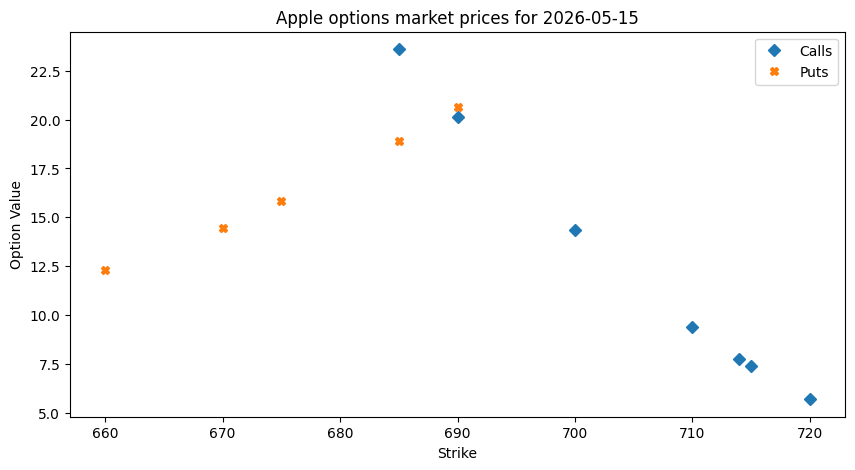

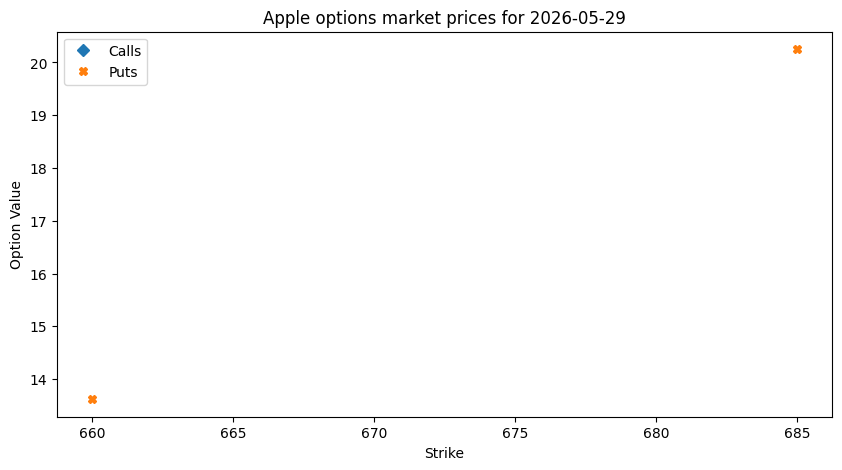

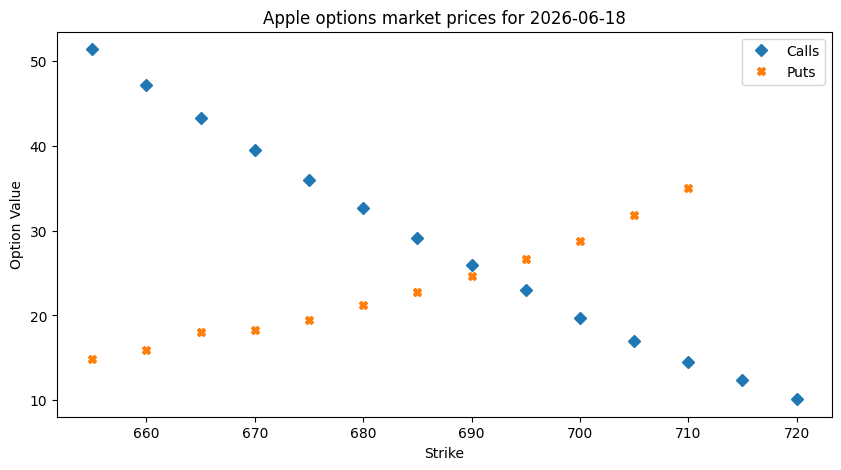

In [5]:
def plot_data(data, columns, labels, title):
    plt.figure(figsize=(10,5))
    for i in range(len(labels)):
        plt.plot(data[i]["strike"], data[i][columns[i]], "D" if i==0 else "X", label=labels[i])
        plt.legend()
        plt.ylabel("Option Value")
        plt.xlabel("Strike")
        plt.title(title)

for expiry in model.data["expiry"].unique():
    options_df = model.data.query("expiry == @expiry")
    plot_data([options_df[options_df["side"]=="Call"], options_df[options_df["side"]=="Put"]], columns=["lastPrice", "lastPrice"],
              labels=["Calls", "Puts"], title=f"Apple options market prices for {expiry}")

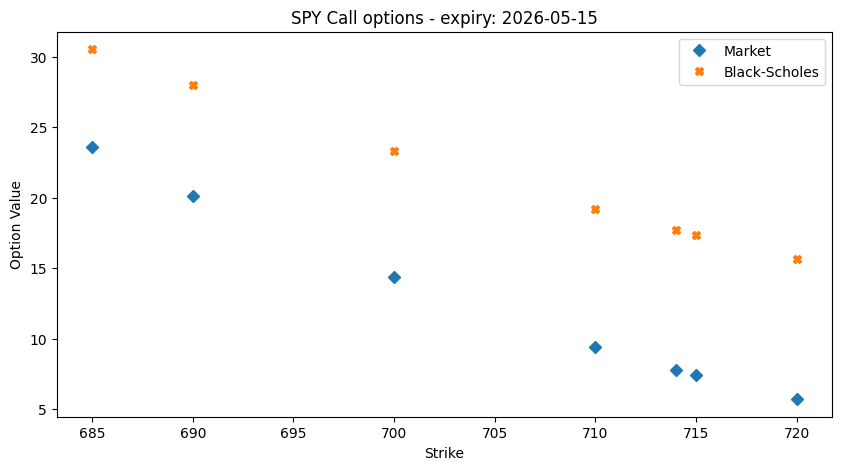

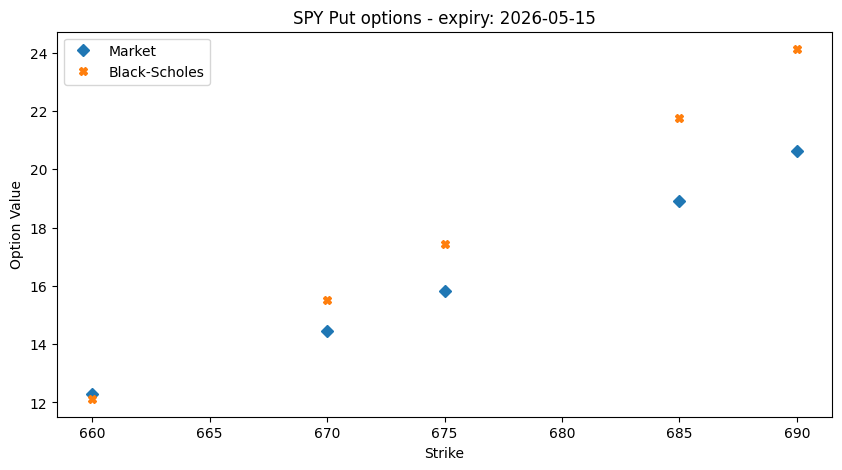

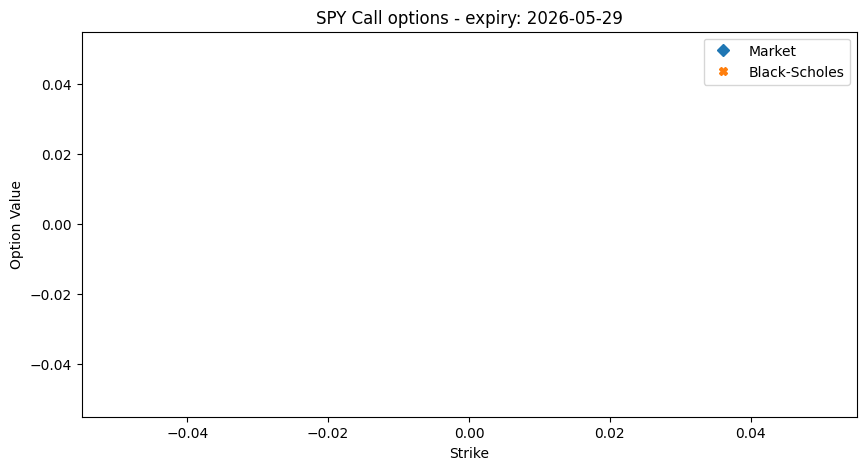

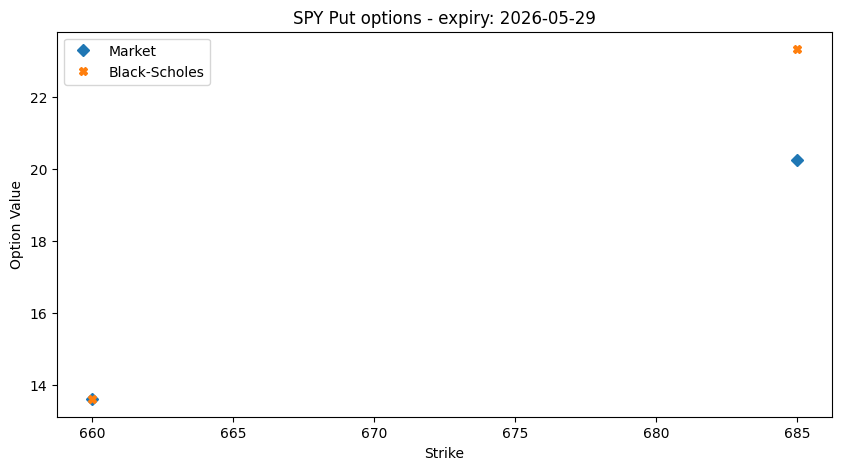

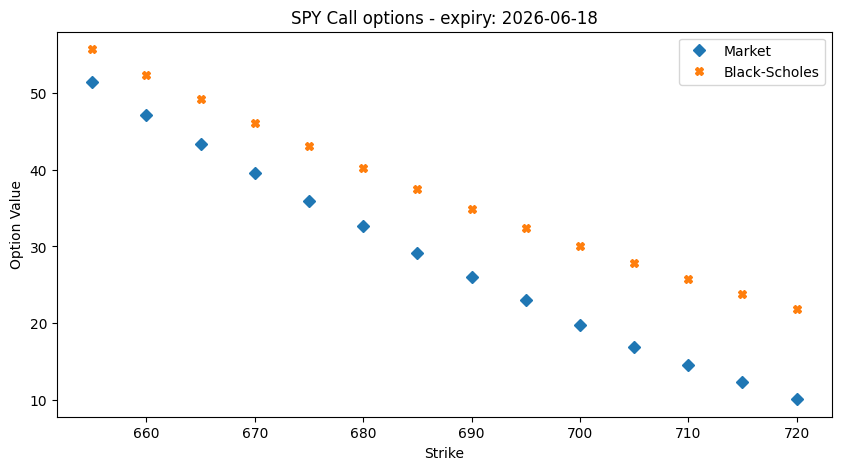

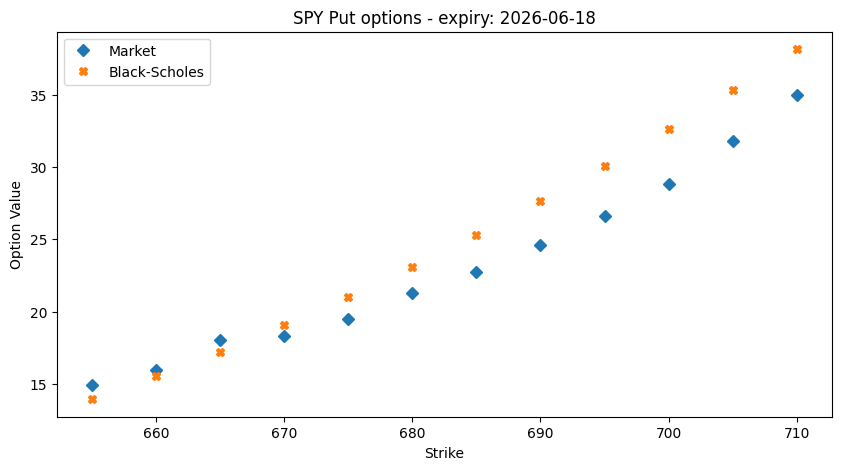

In [6]:
r = 0.0372 # risk free rate
sigma = np.mean(model.data["impliedVolatility"])

model.batch_price_option(model.data, r = 0.0372, params = sigma, return_column="BS_predictions")

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data([options_df[options_df["side"]==side], options_df[options_df["side"]==side]], columns=["lastPrice", "BS_predictions"], 
                  labels=["Market", "Black-Scholes"], title=f"{model.ticker} {side} options - expiry: {expiry}")

The outcome shows that Black-Scholes predictions can be far from the prices we observe in the market, considering the fact that I just guessed r & sigma based on a quick check. Now we are ready to add more complexity to our pricing engine.

## 2) Stochastic volatility model (Heston)
This is a model that adds stochastic behavior to the volatility of the underlying price. It involves additional parameters:
- volatility of the volatility (sigma_v)
- long run average variance (theta_v)
- Initial variance (v0)
- correlation of volatility and price change (rho)
- rate of mean reversion of volatility (kappa_v)

This model can better represent the price movements since it has more details. Here using its characteristic function and Lewis's method of integration, we can price the options. I will modify the price_option() method and include this model type.

In [7]:
def Heston_char_func(self, u, T, r, params):
    # unpacking model params
    kappa_v, theta_v, sigma_v, rho, v0 = params

    c1 = kappa_v * theta_v
    c2 = -np.sqrt((rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2))
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (kappa_v - rho * sigma_v * u * 1j - c2)
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3)))
    H2 = ((kappa_v - rho * sigma_v * u * 1j + c2) / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T))))
    
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

StochasticModel.Heston_char_func = Heston_char_func

def Lewis_cf_integration(self, u, char_func, S0, K, T, r, params):
    char_func_value = char_func(u - 1j * 0.5, T, r, params)
    cf_integration = (1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * char_func_value).real)
    return cf_integration

StochasticModel.Lewis_cf_integration = Lewis_cf_integration

In [8]:
def price_option(self, option_side="Call", S0=None, K=None, T=None, r=None, params=None):

    assert S0 is not None and K is not None and T is not None and r is not None and params is not None, \
            "Parameters 'S0', 'K', 'r' and 'T' are required for pricing"

    if self.model == "black_scholes":
        sigma = params
        d1 = (np.log(S0/K) + ((r + (sigma**2) / 2) * T)) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        norm_cdf = Normal(mu=0, sigma=1).cdf

        if option_side == "Call":
            call_price = S0 * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
            return max(call_price,0)
        else:
            put_price = K * np.exp(-r * T) * norm_cdf(-d2) - S0 * norm_cdf(-d1)
            return max(put_price, 0)
    
    elif self.model == "heston":
        integration_value = quad(lambda u: self.Lewis_cf_integration(u, self.Heston_char_func, S0, K, T, r, params),
        0,
        np.inf,
        limit=250,
    )[0]
        call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * integration_value)

        if option_side == "Call":
            return call_value
        else:
            # for simplicity, I use put-call parity for pricing put options
            return max(0, call_value + K * np.exp(-r * T) - S0)

StochasticModel.price_option = price_option

Now let's compare it with Black-Scholes model. To make it comparable, I set initial and long run variance equal to the market implied volatility. I also set volatility of volatility to the small value of 0.001.

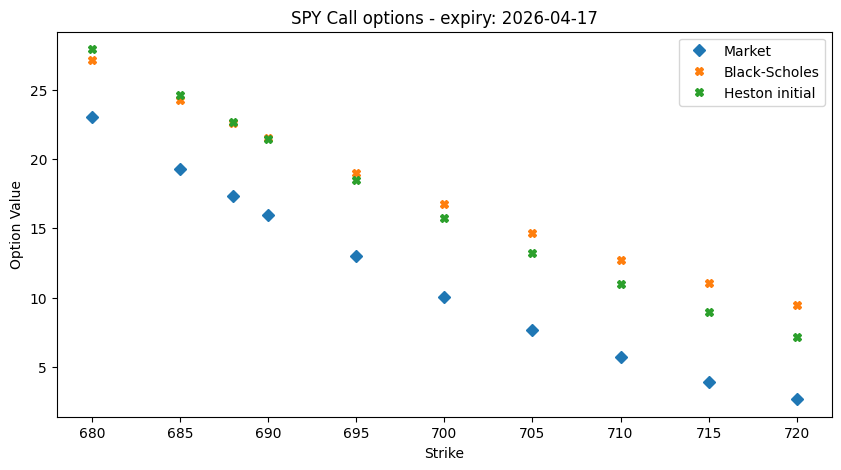

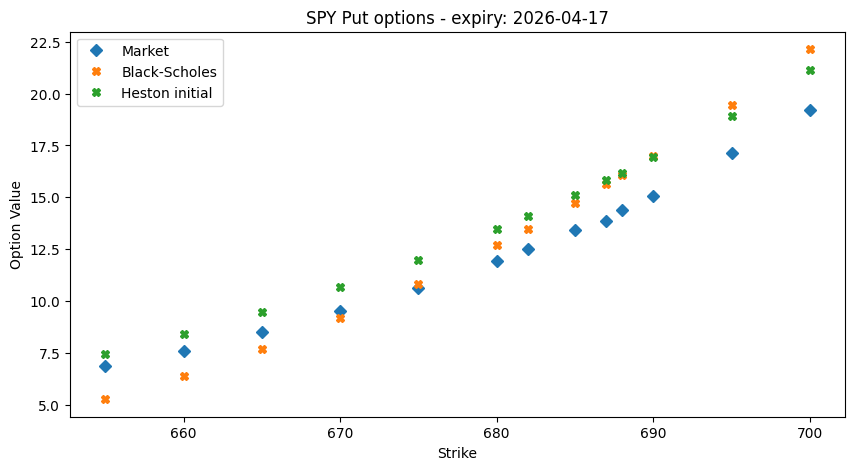

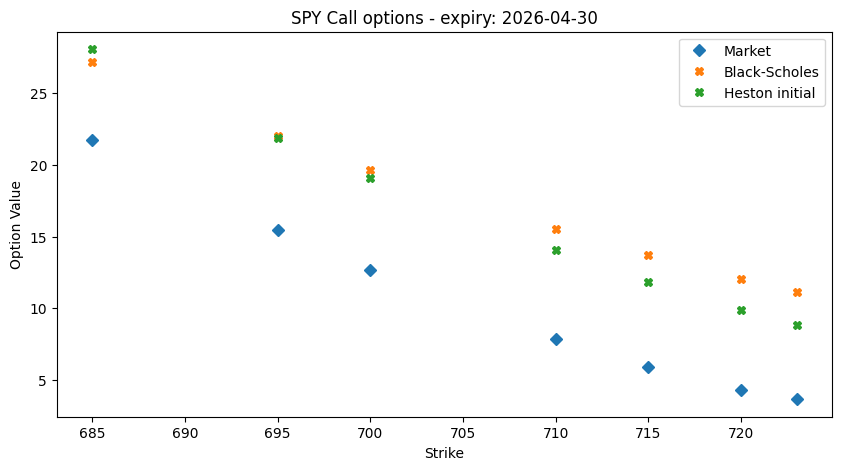

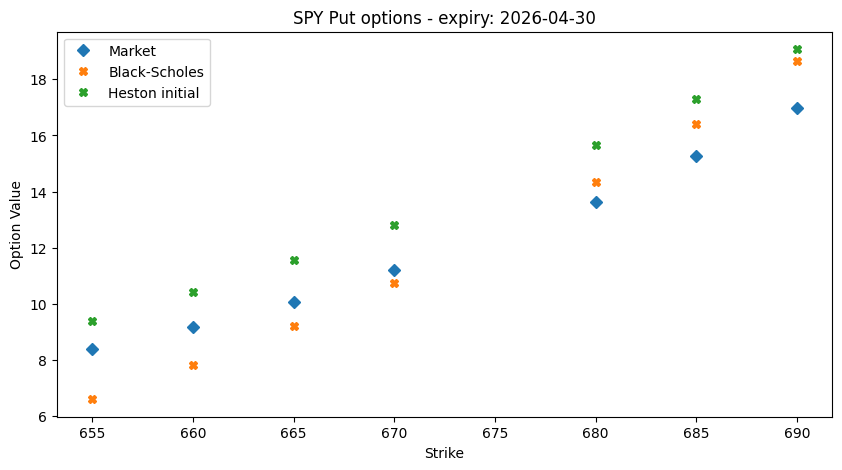

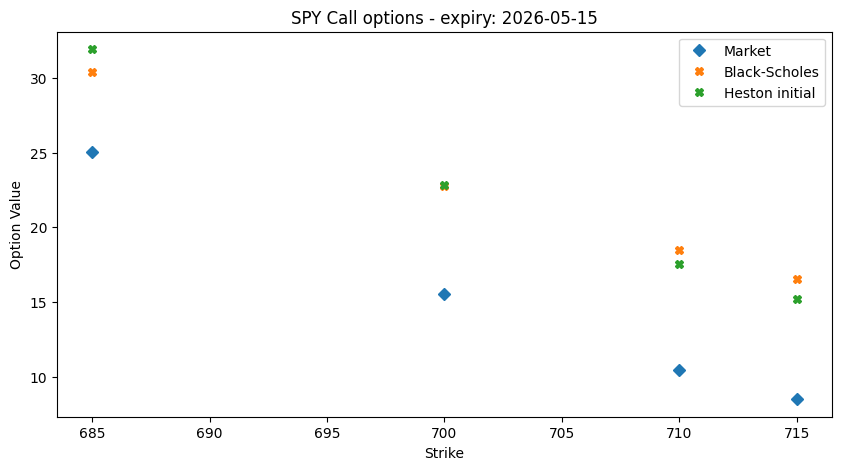

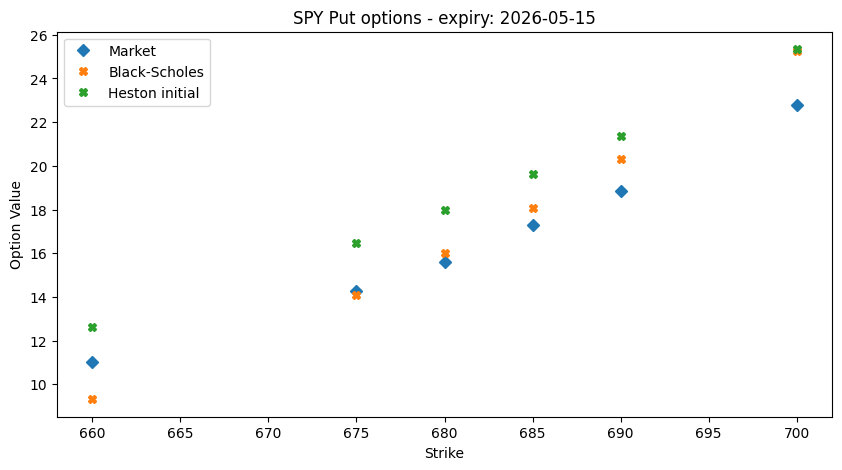

In [9]:
# switching to Heston model
model.model = "heston"
# guessing some values for Heston model:
kappa_v, theta_v, sigma_v, rho, v0 = 0.5, 0.15, 0.5, -0.7, 0.02
# packing model parameters
params = kappa_v, theta_v, sigma_v, rho, v0
model.batch_price_option(model.data, r, params, return_column="Heston_predictions")

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data([options_df, options_df, options_df],
                  columns=["lastPrice", "BS_predictions", "Heston_predictions"],
                  labels=["Market", "Black-Scholes", "Heston initial"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")

The results shows that predictions of the new model can be far from the market observations and also Black-Scholes predictions. The main reason is that the model is not calibrated. The values that I entered for the Heston model parameters, were just some guesses. In a real pricing engine, these values must be calibrated to market before using the model. This is the next step. But before that, let's go back and change the parameters and see how the option price changes.

## 3) Calibration of Heston stochastic volatility model

A straigh-forward way to calibrate the model is to fetch market data, and change the model parameters until we minimize the error between model predictions and market observations. The first step is to implement an error function, that will be our minimization target during the calibration process. This method gets a set of market data along with model parameters. It then runs the model with the input parameters for the same conditions as the market data. Finally it calculates the error based on the error function requested, which can be:
- Mean absolute error
- Mean squared error

In [ ]:
def error_func(self, market_data, r, params, error_type ="mse", print_step=50, print_report=False):

    model_predictions = pd.Series(self.batch_price_option(market_data, r, params))
    if error_type == "mae":
        step_error = np.mean(abs(market_data["lastPrice"] - model_predictions))
    elif error_type == "mse":
        step_error = np.mean((market_data["lastPrice"] - model_predictions) ** 2)

    if step_error < self.quick_min_error:
        self.quick_min_error = step_error
        self.best_params = params

    if self.calib_loop_counter % print_step == 0 and print_report:
        print(f"- Step {self.calib_loop_counter}:  best params: {self.best_params}  |  Min error: {self.quick_min_error.round(3)}")

    self.calib_loop_counter += 1

    return step_error
StochasticModel.error_func = error_func

# add a loop counter instance attribute
def new_init(self,  ticker="aapl", model="black_scholes"):
    self.model = model
    self.ticker = ticker
    self.calib_loop_counter = 0
    self.quick_min_error = 1e9
    self.best_params = None
    print(f"Initialized a {model} model for {ticker}")
StochasticModel.__init__ = new_init
model.__init__("SPY")

Initialized a black_scholes model for SPY


now let's run this method and compare the error of Black-Scholes and Heston models.

In [11]:
model.model="black_scholes"
bs_error = model.error_func(model.data, r=r, params=sigma,  error_type="mse")
model.model="heston"
heston_error = model.error_func(model.data, r=r, params=params, error_type="mse")

print(f"Black-Scholes MAE error: {bs_error.round(3)}")
print(f"Heston MAE error: {heston_error.round(3)}")

Black-Scholes MAE error: 21.187
Heston MAE error: 17.24


A quick calibration, using brute force can be handy when we first want to find a good range of parameters:

In [ ]:
def quick_calibration(self, market_data, r, input_ranges, max_calls, error_type="mse", print_step=50, print_report=False):
    self.calib_loop_counter = 0
    self.quick_min_error = 1e9
    self.fetch_market_data()
    steps = 1
    while (steps + 1) ** len(input_ranges) <= max_calls:
        steps += 1

    print("=" * 70)
    print(f"Quick calibration over {steps} steps, total {steps ** len(input_ranges)} calls...")
    quick_results = brute(lambda x: self.error_func(market_data, r, x, error_type, print_step, print_report), input_ranges, Ns=steps, finish=None)
    return quick_results

StochasticModel.quick_calibration = quick_calibration

In [13]:
model.model="black_scholes"
best_bs_params = model.quick_calibration(model.data, r,
                                         input_ranges=[(0.001, 2)], 
                                         max_calls=201, error_type="mse", print_step=50, print_report=True)

Fetching expiries for traded options of SPY
Fetching market traded options for SPY for expiry at ['2026-02-26']
Fetched data are filtered for min 100 open interest and max 10.0% moneyness threshold
Quick calibration over 201 steps, total 201 calls...
- Step 0:  best params: [0.001]  |  Min error: [142.194]
- Step 50:  best params: [0.130935]  |  Min error: [9.872]
- Step 100:  best params: [0.130935]  |  Min error: [9.872]
- Step 150:  best params: [0.130935]  |  Min error: [9.872]
- Step 200:  best params: [0.130935]  |  Min error: [9.872]


In [14]:
model.model="heston"
best_heston_params = model.quick_calibration(model.data, r,
                                         input_ranges=((0.3,3),
                                                       (0.1,0.6),
                                                       (0.1,0.6),
                                                       (-0.7,0.7),
                                                       (0.01,0.2)
                                                       ), 
                                         max_calls=1025, error_type="mse", print_step=100, print_report=True)

Fetching expiries for traded options of SPY
Fetching market traded options for SPY for expiry at ['2026-02-26']
Fetched data are filtered for min 100 open interest and max 10.0% moneyness threshold
Quick calibration over 4 steps, total 1024 calls...
- Step 0:  best params: [ 0.3   0.1   0.1  -0.7   0.01]  |  Min error: 10.061
- Step 100:  best params: [ 0.3         0.26666667  0.43333333 -0.7         0.01      ]  |  Min error: 4.575
- Step 200:  best params: [ 0.3         0.26666667  0.6        -0.7         0.01      ]  |  Min error: 3.343
- Step 300:  best params: [ 0.3         0.26666667  0.6        -0.7         0.01      ]  |  Min error: 3.343
- Step 400:  best params: [ 0.3         0.26666667  0.6        -0.7         0.01      ]  |  Min error: 3.343
- Step 500:  best params: [ 0.3         0.26666667  0.6        -0.7         0.01      ]  |  Min error: 3.343
- Step 600:  best params: [ 0.3         0.26666667  0.6        -0.7         0.01      ]  |  Min error: 3.343
- Step 700:  best 

Knowing a rough estimation of optimal parameters, now a bounded minimization based on L-BFGS-B algorithm can search deeper for better calibration:

In [ ]:
def calibrate(self, market_data, r, x0, error_type="mse", print_step=50, print_report=False):
    
    self.calib_loop_counter = 0
    self.quick_min_error = 1e9
    self.fetch_market_data()

    if self.model == "black_scholes":
        bounds = [(0.001, 2)]
    elif self.model == "heston":
        bounds = ((0.05, 3), (0.01, 1), (0.01, 1.5), (-1, 1), (0.01, 0.3))
    
    print("=" * 70)
    print(f"Calibrating the function...")
    calib_results = minimize(lambda x: self.error_func(market_data, r, x, error_type, print_step, print_report), x0=x0, bounds=bounds, method="L-BFGS-B")
    return calib_results

StochasticModel.calibrate = calibrate

In [16]:
model.model="heston"
best_heston_params2 = model.calibrate(model.data, r, x0=best_heston_params, error_type="mse", print_step=100, print_report=True)

Calibrating the function...
- Step 1100:  best params: [ 0.18341057  0.22372153  0.61692124 -0.75376782  0.01629701]  |  Min error: 2.567
- Step 1200:  best params: [ 0.32873179  0.24116832  0.82558191 -0.88370019  0.01438177]  |  Min error: 2.058
- Step 1300:  best params: [ 0.36752336  0.23688154  1.00223    -0.8440824   0.01597534]  |  Min error: 2.033
- Step 1400:  best params: [ 0.33232073  0.2600998   1.00481703 -0.84239679  0.01600998]  |  Min error: 2.033
- Step 1500:  best params: [ 0.29436972  0.29254499  1.00771597 -0.83994334  0.01602078]  |  Min error: 2.032
- Step 1600:  best params: [ 0.25456665  0.33267964  0.99106547 -0.84344465  0.01592601]  |  Min error: 2.032
- Step 1700:  best params: [ 0.22154669  0.37938483  0.98861031 -0.84330135  0.01591629]  |  Min error: 2.032
- Step 1800:  best params: [ 0.18143766  0.45911441  0.98538353 -0.84317524  0.01588277]  |  Min error: 2.032
- Step 1900:  best params: [ 0.15436416  0.53741081  0.98944012 -0.84120074  0.01593234]  | 

In [17]:
best_heston_params2.fun, best_heston_params2.x

(np.float64(2.030999898316467),
 array([ 0.08056148,  1.        ,  0.96865791, -0.84392109,  0.01584206]))

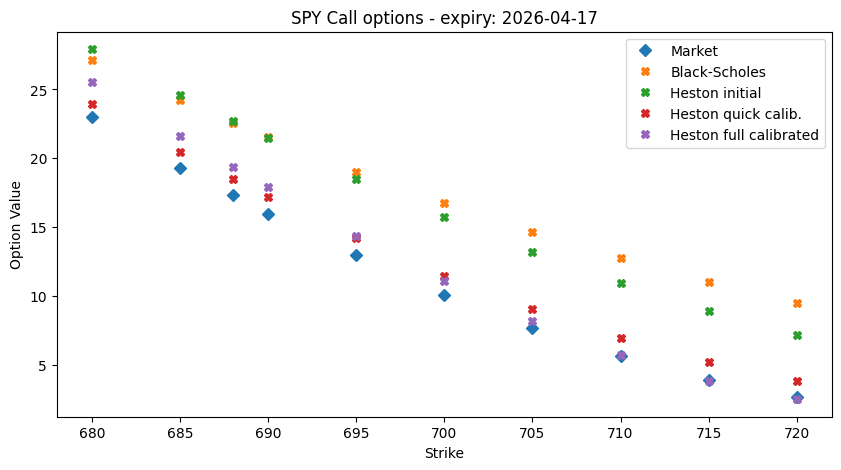

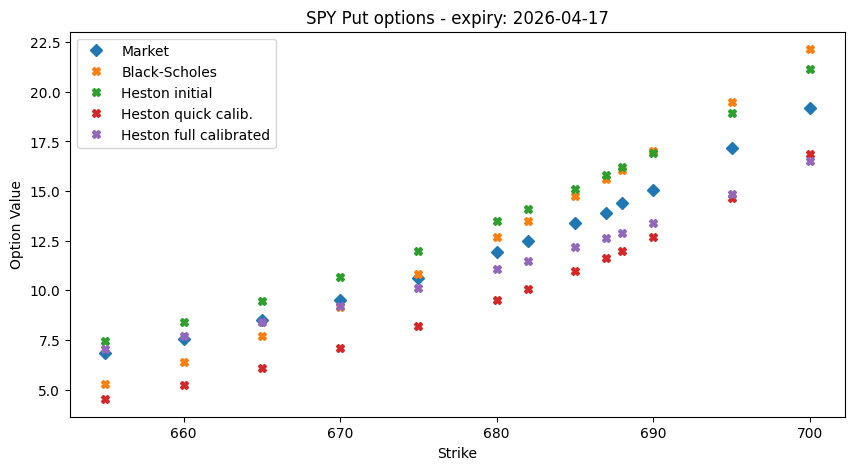

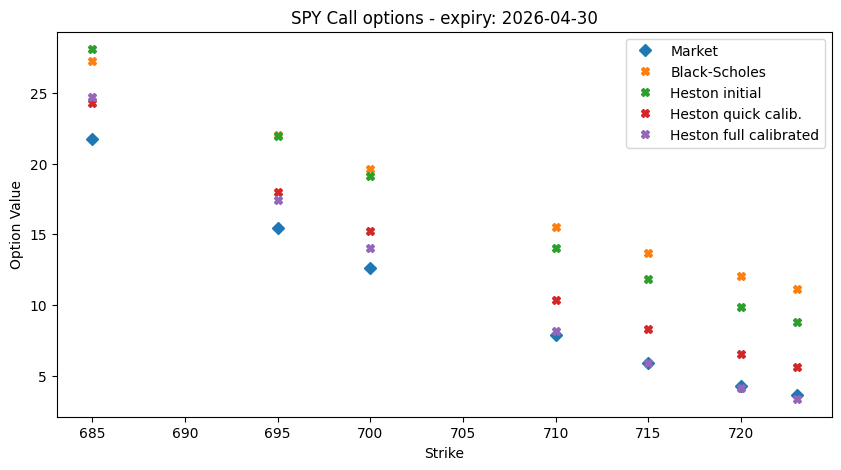

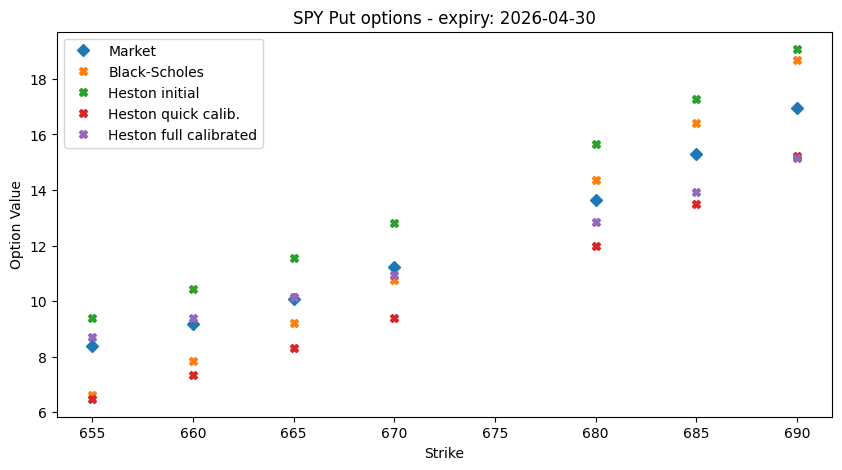

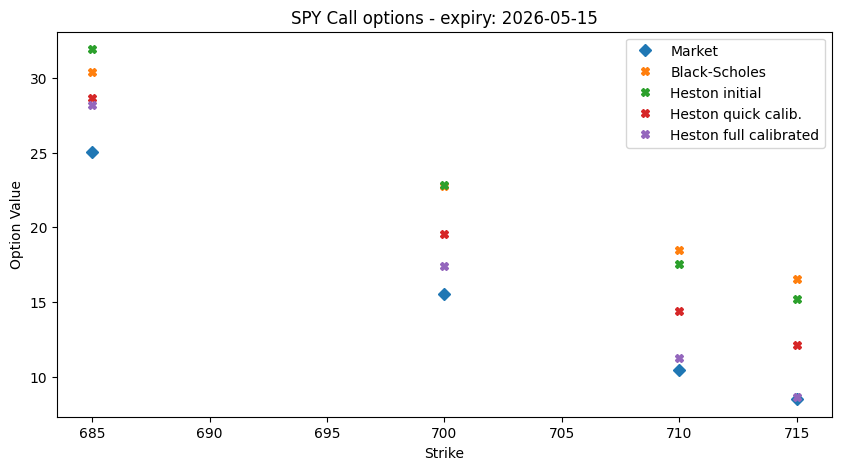

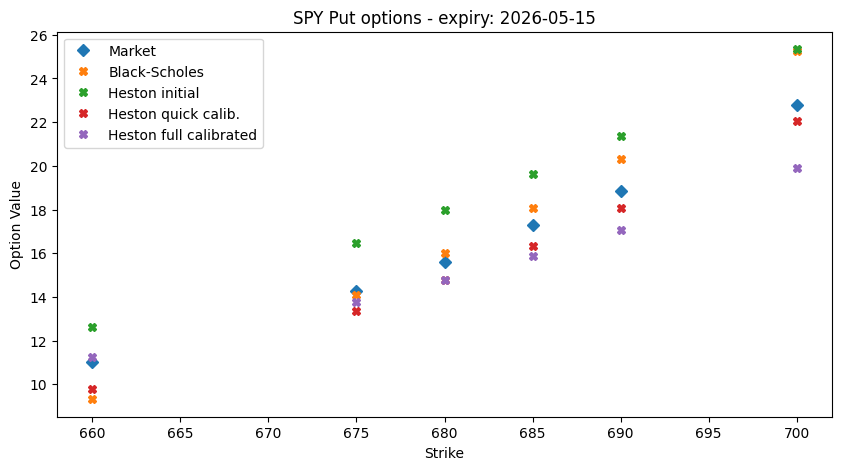

In [ ]:
model.batch_price_option(model.data, r, best_heston_params, return_column="Heston_q_cal")
model.batch_price_option(model.data, r, best_heston_params2.x, return_column="Heston_full_cal")

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data([options_df, options_df, options_df, options_df, options_df],
                  columns=["lastPrice", "BS_predictions", "Heston_predictions", "Heston_q_cal", "Heston_full_cal"],
                  labels=["Market", "Black-Scholes", "Heston initial","Heston quick calib.", "Heston full calibrated"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")

## 4) Adding Merton's jump diffusion

Merton's jump diffusion help model the large price jumps that occur from time to time in the real markets. Heston's stochastic volatility chnges the PDF of price changes move from Gaussian normal distribution towards real case skewness and curtosis. Jump diffusion is the key to add the fat tail characteristics to the model, too. This model has three parameters:
- Expected number of jumps (Poission): lamb
- Mean jump size: mu
- Volatility of jump size: delta

Here we will implement Bates model that includes both the stochastic volatility and jump diffusion, and then attempt to calibrate it.

In [19]:
def Merton_char_func(self, u, T, params):
    lamb, mu, delta = params

    omega = -lamb * (np.exp(mu + 0.5 * delta ** 2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1)) * T)

    return char_func_value

StochasticModel.Merton_char_func = Merton_char_func

def Bates_char_func(self, u, T, r, params):
    kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta = params
    params_Heston = kappa_v, theta_v, sigma_v, rho, v0
    params_Merton = lamb, mu, delta

    H_cf = self.Heston_char_func(u, T, r, params_Heston)
    M_cf = self.Merton_char_func(u, T, params_Merton)

    return H_cf * M_cf

StochasticModel.Bates_char_func = Bates_char_func

Now let's update the price_option method and implement the Bates pricing. We are going to use the Lewis integration here again.

In [20]:
def price_option(self, option_side="Call", S0=None, K=None, T=None, r=None, params=None):

    assert S0 is not None and K is not None and T is not None and r is not None and params is not None, \
            "Parameters 'S0', 'K', 'r' and 'T' are required for pricing"

    if self.model == "black_scholes":
        sigma = params
        d1 = (np.log(S0/K) + ((r + (sigma**2) / 2) * T)) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        norm_cdf = Normal(mu=0, sigma=1).cdf

        if option_side == "Call":
            call_price = S0 * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
            return max(call_price,0)
        else:
            put_price = K * np.exp(-r * T) * norm_cdf(-d2) - S0 * norm_cdf(-d1)
            return max(put_price, 0)


    elif self.model == "heston":
        integration_value = quad(lambda u: self.Lewis_cf_integration(u, self.Heston_char_func, S0, K, T, r, params),
        0,
        np.inf,
        limit=250,
    )[0]
        call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * integration_value)

        if option_side == "Call":
            return call_value
        else:
            # for simplicity, I use put-call parity for pricing put options
            return max(0, call_value + K * np.exp(-r * T) - S0)


    elif self.model == "bates":
        integration_value = quad(lambda u: self.Lewis_cf_integration(u, self.Bates_char_func, S0, K, T, r, params),
        0,
        np.inf,
        limit=250,
    )[0]
        call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * integration_value)

        if option_side == "Call":
            return call_value
        else:
            # for simplicity, I use put-call parity for pricing put options
            return max(0, call_value + K * np.exp(-r * T) - S0)
        
    
StochasticModel.price_option = price_option

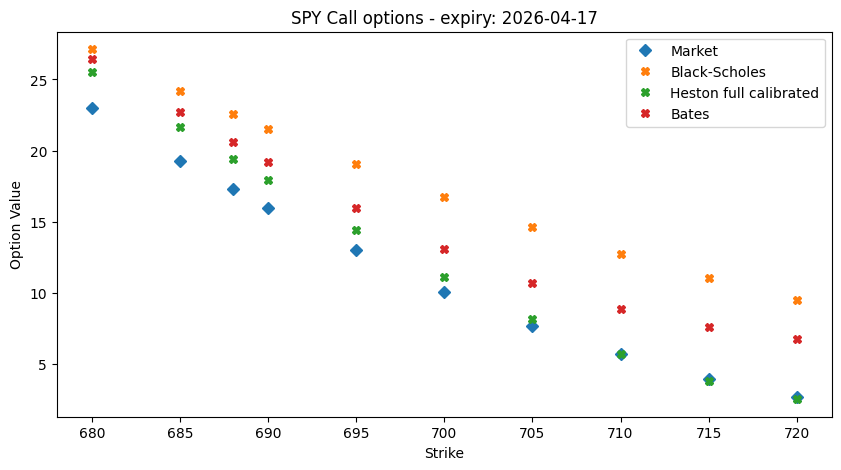

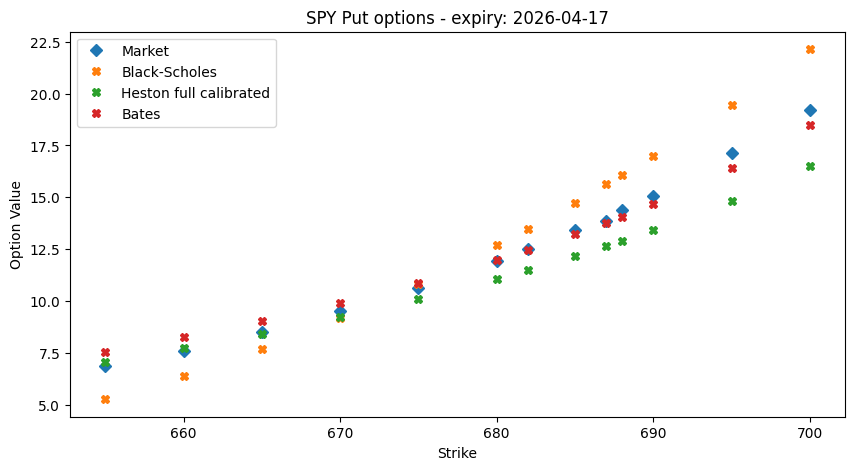

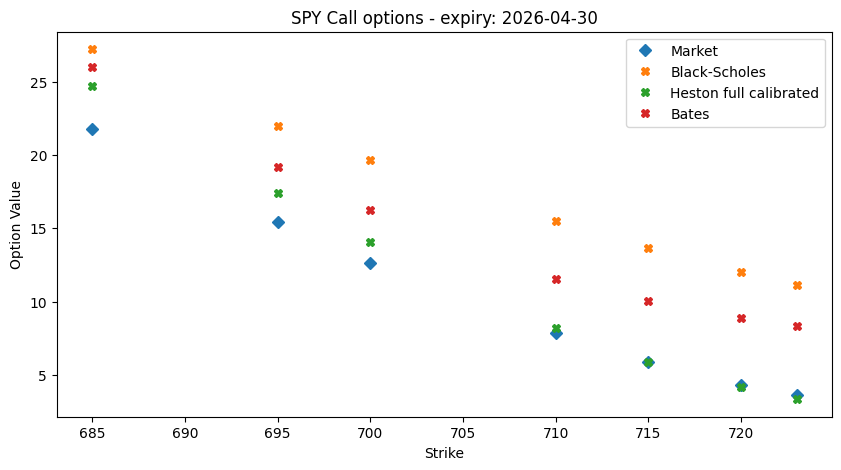

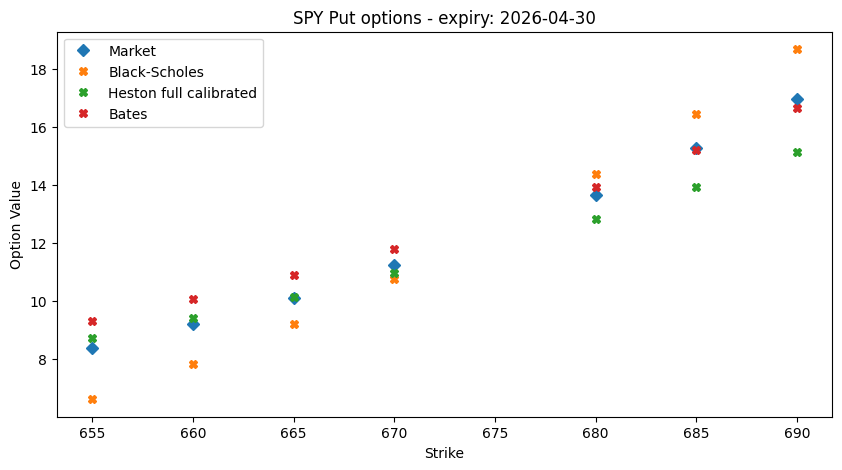

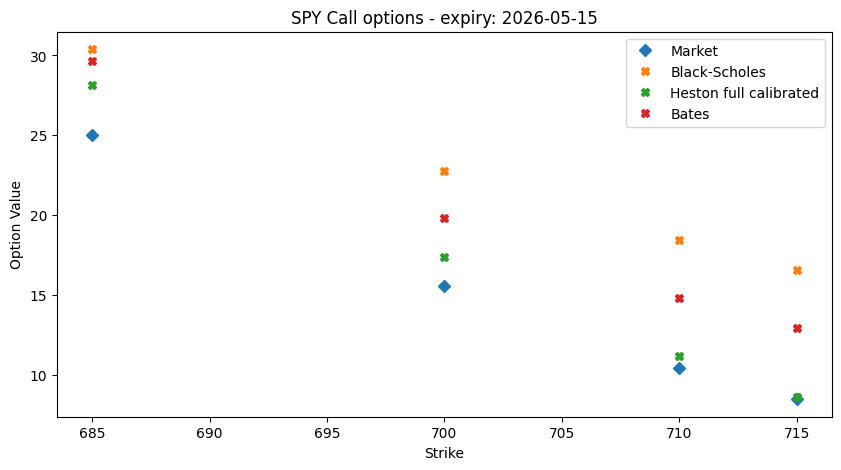

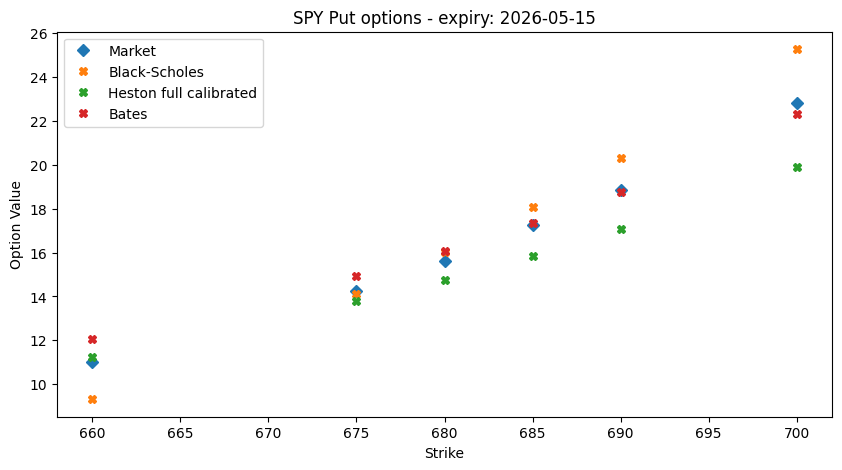

In [21]:
# arbitrary values for Heston model:
kappa_v, theta_v, sigma_v, rho, v0 = best_heston_params2.x
# arbitrary values for Merton model:
lamb, mu, delta = 0.2, 0.2, 0.1
# packing model parameters
bates_params = kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta

model.model="bates"
model.batch_price_option(model.data, r, bates_params, return_column="Bates_predictions")

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data([options_df, options_df, options_df, options_df, options_df],
                  columns=["lastPrice", "BS_predictions", "Heston_full_cal", "Bates_predictions"],
                  labels=["Market", "Black-Scholes", "Heston full calibrated", "Bates"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")

In [22]:
best_bates_params = model.quick_calibration(model.data, r, 
                                         input_ranges=((0.2,2),
                                                       (0.1,0.7),
                                                       (0.1,0.7),
                                                       (-0.6,0.2),
                                                       (0.01,0.2),
                                                       (0.05,1),
                                                       (-0.3,0.3),
                                                       (0.05, 0.7)
                                                       ), 
                                         max_calls=7000, error_type="mse", print_step=200, print_report=True)

Fetching expiries for traded options of SPY
Fetching market traded options for SPY for expiry at ['2026-02-26']
Fetched data are filtered for min 100 open interest and max 10.0% moneyness threshold
Quick calibration over 3 steps, total 6561 calls...
- Step 0:  best params: [ 0.2   0.1   0.1  -0.6   0.01  0.05 -0.3   0.05]  |  Min error: 7.64
- Step 200:  best params: [ 0.2   0.1   0.1  -0.6   0.01  0.05 -0.3   0.7 ]  |  Min error: 7.096
- Step 400:  best params: [ 0.2   0.1   0.4  -0.6   0.01  0.05 -0.3   0.7 ]  |  Min error: 4.767
- Step 600:  best params: [ 0.2   0.1   0.4  -0.6   0.01  0.05 -0.3   0.7 ]  |  Min error: 4.767


KeyboardInterrupt: 

In [102]:
best_bates_params = [ 0.2,   0.1,   0.4,  -0.6,   0.01,  0.05, -0.3,   0.7 ]

In [109]:
def calibrate(self, market_data, r, x0, error_type="mse", print_step=50, print_report=False):
    
    self.calib_loop_counter = 0
    self.quick_min_error = 1e9
    self.fetch_market_data()

    if self.model == "black_scholes":
        bounds = [(0.001, 2)]
    elif self.model == "heston":
        bounds = ((0.05, 5), (0.01, 1), (0.01, 2), (-1, 1), (0.01, 0.5))
    elif self.model == "bates":
        bounds = ((0.05, 5), (0.01, 2), (0.01, 2), (-1, 0.5), (0.01, 0.5),
                  (0.02,4), (-0.3,0.3), (0.05, 0.5))
    
    print("=" * 70)
    print(f"Calibrating the function...")
    calib_results = minimize(lambda x: self.error_func(market_data, r, x, error_type, print_step, print_report), x0=x0, bounds=bounds, method="L-BFGS-B")
    return calib_results

StochasticModel.calibrate = calibrate

In [110]:
model.model = "bates"
best_bates_params2 = model.calibrate(model.data, r, x0 = best_bates_params, error_type="mse", print_step=100, print_report=True)

Fetching expiries for traded options of SPY
Fetching market traded options for SPY for expiry at ['2026-02-26']
Fetched data are filtered for min 100 open interest and max 10.0% moneyness threshold
Calibrating the function...
- Step 100:  best params: [ 0.23843834  0.11471     0.39767358 -0.60384768  0.01        0.08312889
 -0.3         0.49979637]  |  Min error: 3.154
- Step 200:  best params: [ 0.16321416  0.01000001  0.49348171 -0.67609935  0.01069567  0.14694678
 -0.3         0.45651869]  |  Min error: 2.181
- Step 300:  best params: [ 0.24338063  0.09787509  0.52241541 -0.79310734  0.0107659   0.12020466
 -0.29997911  0.30415513]  |  Min error: 2.031
- Step 400:  best params: [ 0.2391196   0.0986042   0.52509744 -0.79358152  0.01087141  0.12041592
 -0.29516754  0.30782505]  |  Min error: 2.031
- Step 500:  best params: [ 0.18721855  0.17751983  0.61540779 -0.87155449  0.01143709  0.13082374
 -0.16129314  0.32921797]  |  Min error: 2.027
- Step 600:  best params: [ 0.180015    0.21

In [111]:
best_bates_params2.x, best_bates_params2.fun

(array([ 0.0502521 ,  0.62641915,  0.57241694, -0.93940855,  0.01067751,
         0.16693936, -0.08355167,  0.31836788]),
 np.float64(2.0212395704381225))

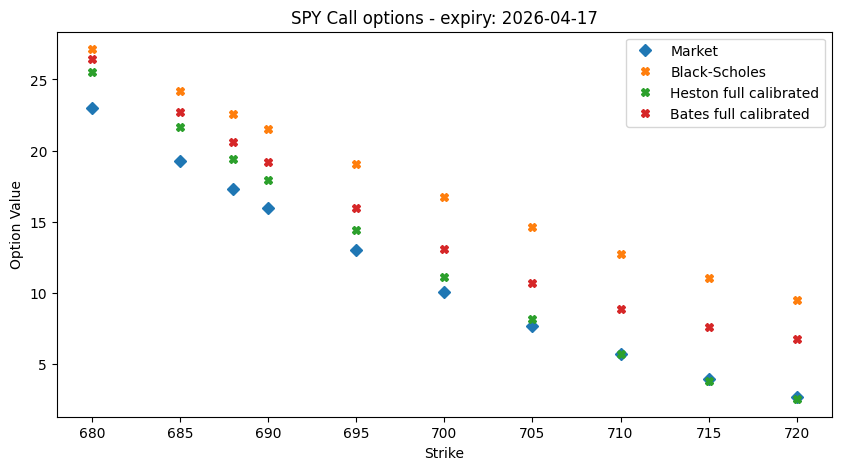

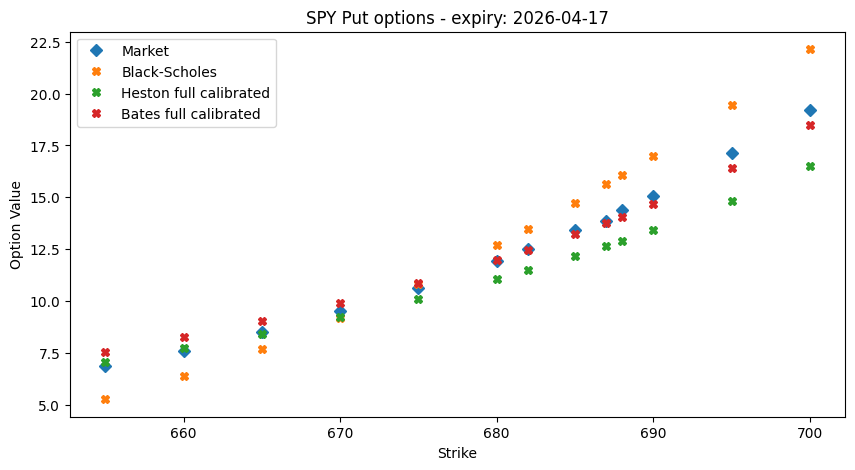

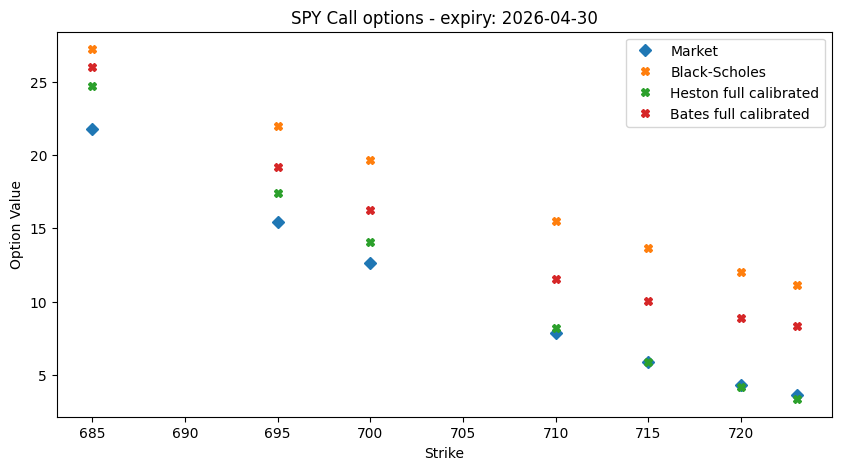

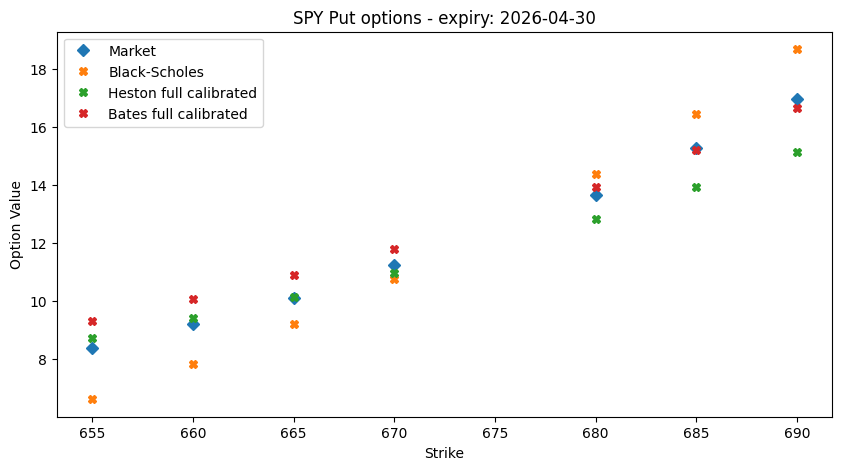

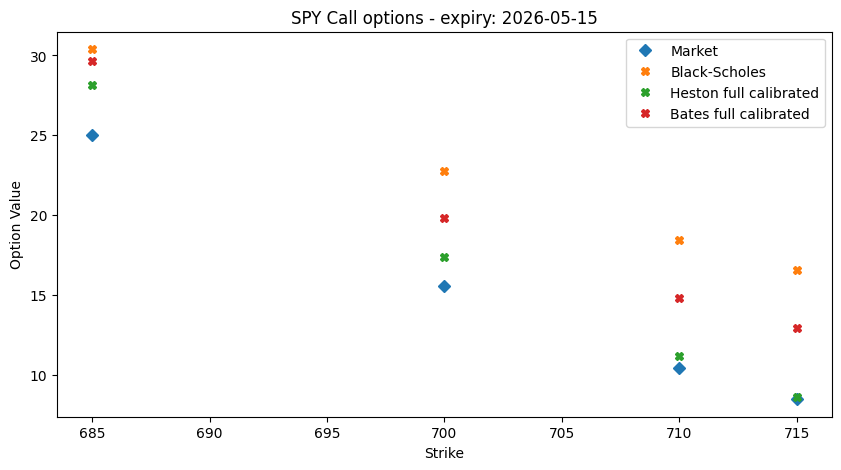

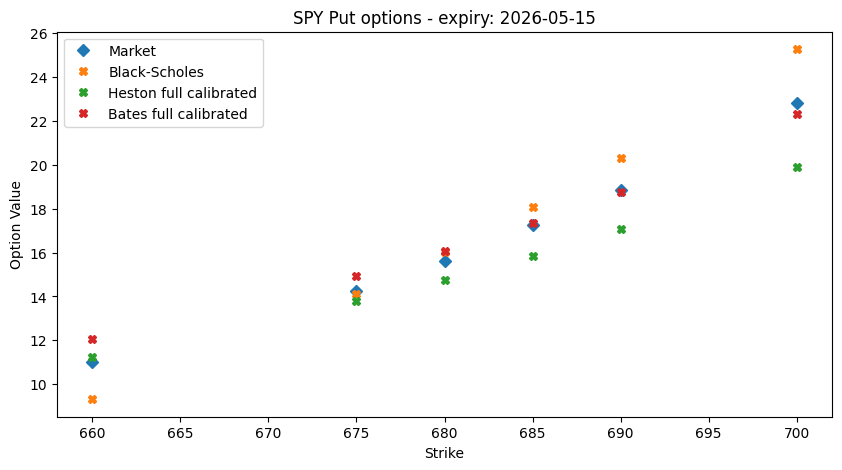

In [112]:
model.model="bates"
model.batch_price_option(model.data, r, bates_params, return_column="Bates_full_cal")

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data([options_df, options_df, options_df, options_df, options_df],
                  columns=["lastPrice", "BS_predictions", "Heston_full_cal", "Bates_full_cal"],
                  labels=["Market", "Black-Scholes", "Heston full calibrated", "Bates full calibrated"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")